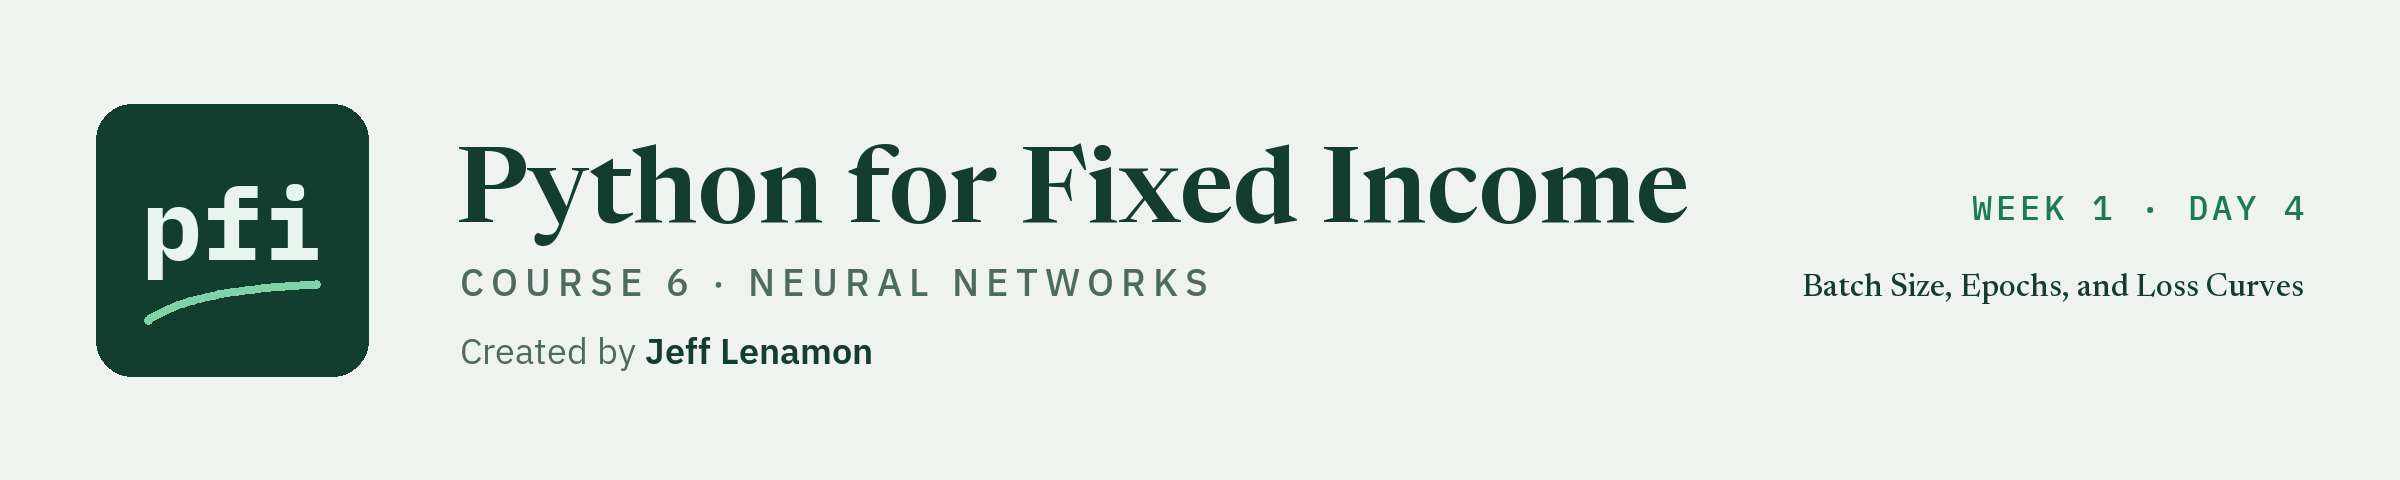

# Batch Size, Epochs, and Loss Curves

Week 1, Day 4. Watch a network fit, epoch by epoch: what an epoch, a batch, and a step are, how to read the loss on the rows it fits and the rows it stops on, how the batch size changes the fitting, when to stop, and how much of a difference is only the seed.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course6_neural_networks/week1/day4/04_batch_size_epochs_and_loss_curves.ipynb)

Days 1 to 3 fitted a neuron and then a small network for a fixed number of passes and looked at where they ended. Today you watch the fitting itself. Keras records the loss after every pass over the rows, on the rows it fits and on rows it never fits, and those two curves answer the questions every later day asks: has the network fitted enough, has it fitted too much, and which pass should be kept.

The settings in play are three numbers you pass to `fit`: the **batch size**, the number of **epochs**, and, through a callback, when to **stop early**. Today changes them one at a time, always on the same network, and judges every change on the 3,600 stopping rows, never on the validation rows.

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` is the UCI file Courses 4 and 5 modelled: 30,000 credit card accounts in Taiwan in 2005, and consumer credit there differs from US credit. Nothing here describes any other market.
* **People's attributes are never features.** `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` are not used by any model, and no output is grouped by them. Every network uses the other 19 columns.
* **Course 4's split, rebuilt.** 18,000 training rows (14,400 to fit and 3,600 to stop or choose), 6,000 validation rows that report, and Course 4's 6,000 test rows closed for the whole course, by day 1's test-row rule.
* **A model's output is described, never acted on.** A network's output is the model probability of default in this file, or a flag at a threshold; a network fitted with class weights gives the model's score. No output of either kind is a credit decision for any person.

Today you will:

1. Count the steps in an epoch (`steps_per_epoch`).
2. Turn the losses Keras records into a table (`history_table`) and draw the two loss curves.
3. Change the batch size at a fixed number of epochs, from 32 rows to all 14,400.
4. Find the epoch where the stopping loss is smallest (`best_epoch`).
5. Fit with early stopping once, and see the epoch it picked and the weights it kept.
6. Read a curve: underfit, fit, overfit.
7. Say where a GPU would help, and why this course does not need one.
8. Refit the same network under five seeds, and measure how much moves with the seed alone.

Q. Set up today's work folder: TensorFlow's settings, the thread settings, the seed, the card file, and the modules as day 3 left them.

In [1]:
# today's setup: the TensorFlow and thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# TensorFlow writes start-up notices to stderr: these three lines must run before TensorFlow is imported
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, TensorFlow, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("tensorflow", "tensorflow"), ("keras", "keras"), ("lightgbm", "lightgbm"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd
import tensorflow as tf
import keras

# one thread for TensorFlow too, set before TensorFlow runs anything
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
# TensorFlow's own Python notices are turned down to errors; on Windows the one it writes is that it has no GPU
# support there (day 1 explains it)
tf.get_logger().setLevel("ERROR")
# where TensorFlow has a deterministic version of an operation, use it
tf.config.experimental.enable_op_determinism()

# the versions the saved outputs of this notebook came from (course6_neural_networks/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "tensorflow": "2.21.0", "keras": "3.15.1", "lightgbm": "4.7.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42
# Keras's seed sets Python's, numpy's, and TensorFlow's random generators at once
keras.utils.set_random_seed(SEED)

# the kinds of device TensorFlow can use on this machine
devices = sorted({device.device_type for device in tf.config.list_physical_devices()})
print(f"Devices TensorFlow can use: {', '.join(devices)}")

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course6_04_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, tensorflow 2.21.0, keras 3.15.1, lightgbm 4.7.0, matplotlib 3.11.2, pytest 9.1.1
Devices TensorFlow can use: CPU
Work folder: pfi_course6_04_h9hrqtqx, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, and `ensemblekit.py`, Course 5's complete module, both unchanged. `netkit` imports them.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)


def bootstrap_interval(y_true, proba, metric, n_boot: int = 1000, level: float = 0.95,
                       seed: int = 42) -> tuple[float, float]:
    """A percentile interval for a metric, from resampling the scored rows.

    Inputs: y_true, the outcomes of the scored rows (0 or 1); proba, the model's outputs on them; metric, a
    function metric(y_true, proba) such as roc_auc_score; n_boot, how many resamples; level, the interval's
    coverage (0.95 for a 95 percent interval); seed, the resampling seed.
    Output: (lower, upper), numpy.percentile (linear) of the n_boot values at (1 - level) / 2 and (1 + level) / 2.
    Convention: each resample draws len(y_true) rows with replacement by np.random.default_rng(seed); a resample
    holding one class only is drawn again. The interval describes the noise from which rows happened to be
    scored, not the noise from refitting the model.
    Excel: =PERCENTILE.INC(range,0.025) and =PERCENTILE.INC(range,0.975) on the pasted resampled values.
    Raises ValueError on inputs of different lengths, fewer than both classes, n_boot below 1, or level outside
    (0, 1).
    """
    actual, scores = np.asarray(y_true), np.asarray(proba, dtype=float)
    if actual.size == 0 or actual.shape != scores.shape:
        raise ValueError(f"y_true and proba must be non-empty and the same length, not {actual.size} and {scores.size}")
    if len(np.unique(actual)) < 2:
        raise ValueError("y_true must hold both classes")
    if n_boot < 1 or not 0 < level < 1:
        raise ValueError(f"n_boot must be at least 1 and level between 0 and 1, not {n_boot}, {level}")
    rng = np.random.default_rng(seed)
    values = []
    while len(values) < n_boot:
        rows = rng.integers(0, actual.size, actual.size)
        # a resample with one class has no ROC AUC; draw again
        if len(np.unique(actual[rows])) < 2:
            continue
        values.append(metric(actual[rows], scores[rows]))
    lower, upper = np.percentile(values, [100 * (1 - level) / 2, 100 * (1 + level) / 2])
    return float(lower), float(upper)


from sklearn.model_selection import cross_val_score  # one score per fold


def course4_polish_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish bankruptcy file, without its 1,170 test rows.

    Input: frame, the 5,910 rows of polish_bankruptcy_5year.csv read with float_precision="round_trip".
    Output: X_train (Attr1 to Attr64, missing values kept) and y_train (class), 4,680 rows, 326 of them bankrupt,
    with the file's row labels. Course 4's 1,170 test rows are never returned.
    Convention: Course 4's capstone steps: exact duplicate rows dropped (5,910 to 5,850), then
    train_test_split(test_size=0.2, stratify=y, random_state=42).
    Raises ValueError if the frame does not hold 5,910 rows with a class column.
    """
    if len(frame) != 5_910 or "class" not in frame.columns:
        raise ValueError(f"frame must be the 5,910 rows of the Polish file with a class column, not {len(frame)} rows")
    unique = frame.drop_duplicates()
    X, y = unique.drop(columns="class"), unique["class"]
    # Course 4's split: the second part was its test set, dropped here
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_train, y_train


def nested_score(search, X, y, outer=None, scoring: str = "average_precision") -> pd.Series:
    """An honest score for a tuned model: the whole search is repeated inside each outer fold.

    Inputs: search, an unfitted RandomizedSearchCV or GridSearchCV that carries its own inner cv; X, y, the
    training rows; outer, the outer splitter (default mlkit.cv_folds()); scoring, the metric.
    Output: one score per outer fold, indexed fold_1, fold_2, ...: each fold's search tunes on the other folds
    only and is scored on its own held-out rows (cross_val_score, n_jobs=1).
    Convention: a search's best_score_ is the best of many noisy numbers and is not an honest score of the model it
    chose; the mean of this Series is.
    Raises ValueError if the search has no inner cv.
    """
    if getattr(search, "cv", None) is None:
        raise ValueError("give the search its own inner cv, for example StratifiedKFold(3, shuffle=True, random_state=42)")
    folds = outer if outer is not None else mlkit.cv_folds()
    scores = cross_val_score(search, X, y, cv=folds, scoring=scoring, n_jobs=1)
    return pd.Series(scores, index=[f"fold_{i}" for i in range(1, len(scores) + 1)], name=scoring)


def search_table(search, top: int = 5) -> pd.DataFrame:
    """A fitted search's results as a short table, best first.

    Inputs: search, a fitted RandomizedSearchCV or GridSearchCV; top, how many candidates to keep.
    Output: columns rank, mean, sd (the mean and standard deviation of the fold scores, ddof=0, as cv_results_),
    then one column per searched parameter (the param_ prefix dropped), sorted by rank.
    Excel: =AVERAGE and =STDEV.P of a candidate's five fold scores give its mean and sd (STDEV.S does not).
    Raises ValueError if the search is not fitted.
    """
    if not hasattr(search, "cv_results_"):
        raise ValueError("the search is not fitted: call fit first")
    results = pd.DataFrame(search.cv_results_)
    params = [name for name in results.columns if name.startswith("param_")]
    table = results[["rank_test_score", "mean_test_score", "std_test_score"] + params]
    table.columns = ["rank", "mean", "sd"] + [name[len("param_"):] for name in params]
    return table.sort_values("rank", kind="stable").head(top).reset_index(drop=True)


from sklearn.base import BaseEstimator, TransformerMixin  # what makes a class a scikit-learn transformer
from sklearn.utils.validation import check_is_fitted  # stops a transformer used before fit


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """A ratio of two columns that is never infinite: missing where the denominator is 0 or either side is missing.

    Inputs: numerator, denominator, two Series with the same row labels.
    Output: numerator / denominator as floats, with NaN where the denominator is 0 or either value is missing.
    Convention: a model that handles missing values (or an imputer inside a pipeline) then deals with those rows;
    an infinity would break most estimators.
    Excel: =IF(OR(B2=0,B2="",A2=""),NA(),A2/B2), where =A2/B2 alone gives #DIV/0!.
    Raises ValueError if the two Series do not have the same row labels.
    """
    if not numerator.index.equals(denominator.index):
        raise ValueError("numerator and denominator must have the same row labels")
    defined = denominator.ne(0) & numerator.notna() & denominator.notna()
    # divide only where the ratio is defined; every other row stays NaN
    return numerator.astype(float).div(denominator.astype(float).where(defined)).where(defined)


class ClipToTraining(TransformerMixin, BaseEstimator):
    """Clip each column to bounds learned from the rows it is fitted on (by default the 1st and 99th percentiles).

    Inside a pipeline, fit sees only each fold's training rows, so the bounds never come from held-out rows.
    Parameters: lower, upper, the quantiles (0 <= lower < upper <= 1).
    Fitted attributes: lower_, upper_, one bound per column (numpy.nanquantile, linear, missing values ignored);
    n_features_in_; feature_names_in_ when fitted on a DataFrame.
    transform returns a float array; a missing value stays missing.
    Excel: =PERCENTILE.INC(training_range,0.01) and 0.99 give the bounds; =MIN(MAX(x,low),high) clips.
    """

    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(f"need 0 <= lower < upper <= 1, not {self.lower}, {self.upper}")
        values = np.asarray(X, dtype=float)
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = values.shape[1]
        # each column's bounds, from these rows only
        self.lower_ = np.nanquantile(values, self.lower, axis=0)
        self.upper_ = np.nanquantile(values, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["lower_", "upper_"])
        values = np.asarray(X, dtype=float)
        if values.shape[1] != self.n_features_in_:
            raise ValueError(f"X has {values.shape[1]} columns, the transformer was fitted on {self.n_features_in_}")
        return np.clip(values, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["lower_", "upper_"])
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)


def class_counts_after(sampler, X, y) -> pd.Series:
    """How many rows of each class a resampler leaves: for showing what a sampler does.

    Inputs: sampler, an imbalanced-learn sampler such as SMOTE(random_state=42); X, y, rows with no missing value.
    Output: the count of each class after sampler.fit_resample(X, y), indexed by class.
    Convention: a demonstration only. Rows a model is scored on are never resampled; resampling belongs inside an
    imblearn pipeline, where cross-validation resamples each fold's training rows only.
    """
    _, y_resampled = sampler.fit_resample(X, y)
    return pd.Series(y_resampled).value_counts().sort_index()


def prior_correction(score, fitted_rate: float, true_rate: float) -> np.ndarray:
    """Move a score from a model fitted at one outcome rate back to the rate of the real rows.

    Inputs: score, the model's outputs (between 0 and 1); fitted_rate, the outcome rate of the rows the model was
    fitted on (0.5 after SMOTE to balance); true_rate, the outcome rate of the real training rows.
    Output: each score's odds multiplied by k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate)),
    turned back into a number between 0 and 1: s * k / (s * k + 1 - s).
    Convention: a closed form that assumes resampling changed only the class shares; it leaves the ranking of rows
    unchanged. Equal rates give the score back.
    Excel: k in one cell, =(t/(1-t))/(f/(1-f)), then =p*k/(p*k+1-p) filled down.
    Raises ValueError if a rate is not strictly between 0 and 1 or a score is outside [0, 1].
    """
    for name, rate in (("fitted_rate", fitted_rate), ("true_rate", true_rate)):
        if not 0 < rate < 1:
            raise ValueError(f"{name} must be strictly between 0 and 1, not {rate}")
    s = np.asarray(score, dtype=float)
    if s.size == 0 or (s < 0).any() or (s > 1).any():
        raise ValueError("score must be non-empty and between 0 and 1")
    # the factor that moves odds from the fitted rate to the true rate
    k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate))
    return s * k / (s * k + 1 - s)


import re  # whole-word search

# words that turn a description of a model into a claim about causes; a reminder, not a proof
EXPLANATION_WORDS = ["cause", "causes", "caused", "driver", "drivers", "drives", "reason", "reasons", "because"]


def shap_table(shap_values, top: int | None = None) -> pd.DataFrame:
    """Mean absolute SHAP value per feature, largest first.

    Inputs: shap_values, a shap.Explanation for one output (rows by features), for example
    shap.TreeExplainer(model)(X); top, how many features to keep (all if None).
    Output: a DataFrame indexed by feature with columns mean_abs_shap (the average size of the feature's
    contribution to the model's log-odds, in log-odds) and rank (1 = largest).
    Convention: a SHAP value describes how the model's output for a row splits across features; it is not the
    effect of changing a feature and not a cause.
    Excel: =AVERAGE(ABS(column)) on a pasted column of SHAP values.
    Raises ValueError if the values are not one row per observation and one column per feature.
    """
    values = np.asarray(shap_values.values, dtype=float)
    if values.ndim != 2 or values.shape[1] != len(shap_values.feature_names):
        raise ValueError(f"expected rows by features, got shape {values.shape}")
    table = pd.DataFrame({"mean_abs_shap": np.abs(values).mean(axis=0)},
                         index=pd.Index(shap_values.feature_names, name="feature"))
    table = table.sort_values("mean_abs_shap", ascending=False, kind="stable")
    table["rank"] = np.arange(1, len(table) + 1)
    return table if top is None else table.head(top)


def assert_additive(shap_values, raw_score, tol: float = 1e-9) -> None:
    """Stop unless each row's SHAP values add up to the model's raw output (log-odds).

    Inputs: shap_values, a shap.Explanation for one output; raw_score, the model's log-odds for the same rows
    (LightGBM: predict(X, raw_score=True); XGBoost: predict(X, output_margin=True)); tol, the largest gap allowed
    (1e-9 for LightGBM; 1e-5 for XGBoost, which computes in float32).
    Output: None when base value + the row's SHAP values equals raw_score in every row within tol.
    Convention: the contributions add up in log-odds, not in probability; mlkit.logistic_probability turns the sum
    into the model's probability.
    Raises AssertionError naming the largest gap and its row position, and ValueError on lengths that differ.
    """
    values = np.asarray(shap_values.values, dtype=float)
    raw = np.asarray(raw_score, dtype=float)
    if values.ndim != 2 or values.shape[0] != raw.size:
        raise ValueError(f"shap_values has {values.shape[0]} rows and raw_score {raw.size}")
    # base value plus the row's contributions, against the model's own log-odds
    gaps = np.abs(np.asarray(shap_values.base_values, dtype=float) + values.sum(axis=1) - raw)
    worst = int(np.argmax(gaps))
    if gaps[worst] > tol:
        raise AssertionError(f"SHAP values do not add up to raw_score: largest gap {gaps[worst]:.3g} at row "
                             f"position {worst} (tolerance {tol:g}); raw_score must be log-odds, not a probability")


def assert_described(text: str) -> None:
    """Stop if a written description uses a forecast word or a cause word.

    Input: text, a description of what a model shows.
    Output: None if the text passes mlkit.assert_descriptive and holds no word of EXPLANATION_WORDS as a whole word,
    in any case.
    Convention: the lists are a reminder, not a proof. "because" is on the list so the writer looks again at every
    causal sentence; a description that needs it rewrites the sentence.
    Raises ValueError naming the words found.
    """
    mlkit.assert_descriptive(text)
    found = [word for word in EXPLANATION_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses cause or explanation words: {found}")

Writing ensemblekit.py


Q. Write `netkit.py` and `test_netkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [4]:
%%writefile netkit.py
"""netkit: the pieces of neural networks that Keras leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 6: Neural Networks. It imports mlkit (Course 4's module) and
ensemblekit (Course 5's module) and never changes either.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one. Every function that builds a Keras model calls
  keras.utils.set_random_seed(seed) first, so a model's numbers do not depend on what ran before it.
- Keras runs quietly: verbose=0 on every fit, predict, and evaluate.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 6 never scores a row that an earlier course used as a test row: rows come from ensemblekit.course4_*_rows.
- Rows that fit a network, rows that stop or choose, and rows that report a result are kept apart. A scaler is
  fitted on the fit rows only (fit_arrays).
- Changes and errors on the Treasury curve are in basis points (bp).
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import os

# TensorFlow reads these when it is imported. setdefault keeps whatever a notebook's setup cell already set, and
# quiets TensorFlow's start-up notices when the tests run from PowerShell.
os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
import tensorflow as tf  # tensors and automatic gradients
import keras  # networks: layers, optimizers, losses

import ensemblekit  # Course 5's module: the card, benchmark, and Polish rows, stopping rows, mae_bp
import mlkit  # Course 4's module: folds, thresholds, metrics, and the no-leak checks


def _labels_and_scores(y, p) -> tuple[np.ndarray, np.ndarray]:
    """y and p as float64 arrays of the same length, y holding only 0 and 1; raises ValueError otherwise."""
    labels = np.asarray(y, dtype=float).ravel()
    scores = np.asarray(p, dtype=float).ravel()
    if labels.size == 0 or labels.size != scores.size:
        raise ValueError(f"y and p must be non-empty and the same length, not {labels.size} and {scores.size}")
    if not np.isin(labels, (0.0, 1.0)).all():
        raise ValueError("y must hold only 0 and 1")
    return labels, scores


def mean_log_loss(y, p, epsilon: float = 1e-7) -> float:
    """The mean log loss (binary cross-entropy) of outputs p for outcomes y.

    Inputs: y, outcomes (0 or 1); p, the model's outputs, between 0 and 1, the same length; epsilon, how far from 0
    and 1 each output is clipped.
    Output: mean of -(y ln p + (1 - y) ln(1 - p)), with p clipped to [epsilon, 1 - epsilon] as Keras clips (its
    default epsilon is 1e-7). Equals sklearn.metrics.log_loss within 1e-12 when no output is clipped.
    Excel: =-(B2*LN(C2)+(1-B2)*LN(1-C2)) filled down, then =AVERAGE of the column.
    Raises ValueError on lengths that differ or labels other than 0 and 1.
    """
    labels, scores = _labels_and_scores(y, p)
    # keep every output inside (0, 1), so no logarithm is of 0
    clipped = np.clip(scores, epsilon, 1 - epsilon)
    return float(np.mean(-(labels * np.log(clipped) + (1 - labels) * np.log(1 - clipped))))


def _neuron_inputs(w, b: float, X, y) -> tuple[np.ndarray, float, np.ndarray, np.ndarray]:
    """w, X, y as float64 arrays that line up with each other; raises ValueError otherwise."""
    weights = np.asarray(w, dtype=float).ravel()
    rows = np.asarray(X, dtype=float)
    if rows.ndim != 2 or rows.shape[0] == 0:
        raise ValueError(f"X must be a non-empty 2-D array of rows by columns, not shape {rows.shape}")
    if rows.shape[1] != weights.size:
        raise ValueError(f"X has {rows.shape[1]} columns but w has {weights.size} weights")
    labels, _ = _labels_and_scores(y, np.zeros(rows.shape[0]))
    return weights, float(b), rows, labels


def log_loss_gradient(w, b: float, X, y) -> tuple[np.ndarray, float]:
    """The gradient of the mean log loss of one sigmoid neuron, worked by hand.

    Inputs: w, one weight per column of X; b, the intercept; X, the rows (rows by columns); y, the outcomes (0 or 1).
    Output: (gradient for the weights, gradient for the intercept), in float64: ((p - y) @ X / n, mean(p - y)),
    where p = 1 / (1 + exp(-(X @ w + b))) and n is the number of rows.
    Convention: the gradient is averaged over the rows, as Keras averages the loss over a batch. Equals
    tf.GradientTape on float64 tensors within 1e-12.
    Excel: =SUMPRODUCT(C2:C18001-B2:B18001,A2:A18001)/ROWS(A2:A18001) for a weight and
    =SUMPRODUCT(C2:C18001-B2:B18001)/ROWS(A2:A18001) for the intercept.
    Raises ValueError if the shapes do not line up or y holds labels other than 0 and 1.
    """
    weights, intercept, rows, labels = _neuron_inputs(w, b, X, y)
    # the neuron's output for each row, then how far it is from the outcome
    p = 1 / (1 + np.exp(-(rows @ weights + intercept)))
    error = p - labels
    return error @ rows / rows.shape[0], float(error.mean())


def gradient_step(w, b: float, X, y, learning_rate: float) -> tuple[np.ndarray, float]:
    """One full-batch step of gradient descent for one sigmoid neuron.

    Inputs: w, b, X, y as log_loss_gradient; learning_rate, the size of the step (above 0).
    Output: (w - learning_rate * gradient for the weights, b - learning_rate * gradient for the intercept).
    Convention: a learning rate that is too large makes the loss rise instead of fall.
    Excel: =$H$2-$H$5*$H$7 for each weight, with the gradient in its own cell.
    Raises ValueError unless learning_rate > 0, and as log_loss_gradient.
    """
    if not learning_rate > 0:
        raise ValueError(f"learning_rate must be above 0, not {learning_rate}")
    gradient_w, gradient_b = log_loss_gradient(w, b, X, y)
    return np.asarray(w, dtype=float).ravel() - learning_rate * gradient_w, float(b) - learning_rate * gradient_b


from sklearn.base import clone  # a fresh, unfitted copy of a transformer


def fit_arrays(transformer, X_fit, *others) -> tuple:
    """Fit a scaler (or any scikit-learn transformer) on the fit rows only, then transform every set of rows.

    Inputs: transformer, an unfitted scikit-learn transformer, for example StandardScaler(), a ColumnTransformer,
    or a Pipeline of an imputer and a QuantileTransformer; X_fit, the rows the network is fitted on; others, any
    other sets of rows (stopping rows, validation rows, a held-out fold).
    Output: (fitted, A_fit, *A_others): a clone of transformer fitted on X_fit only, and float32 arrays of X_fit and
    of each of others transformed by that fitted copy.
    Convention: this is the course's one way to scale rows for a network. The rows in others are never seen by the
    fit, so their statistics cannot leak into the scaling.
    Raises ValueError if X_fit is empty.
    """
    if len(X_fit) == 0:
        raise ValueError("X_fit is empty")
    # a clone, so the transformer passed in stays unfitted and can be used again
    fitted = clone(transformer).fit(X_fit)
    arrays = [np.asarray(fitted.transform(rows), dtype="float32") for rows in (X_fit, *others)]
    return (fitted, *arrays)


def neuron_coefficients(model, names: list[str]) -> pd.Series:
    """The intercept and weights of a network that is one neuron.

    Inputs: model, a Keras model with exactly one Dense layer of one unit; names, the input columns' names.
    Output: a Series indexed intercept, then names, in the model's input units (scaled inputs give weights per
    standard deviation). With a sigmoid output these are log-odds coefficients, as a logistic regression's.
    Raises ValueError if the model has another Dense layer, the layer has more than one unit, or names has the
    wrong length.
    """
    dense = [layer for layer in model.layers if isinstance(layer, keras.layers.Dense)]
    if len(dense) != 1 or dense[0].units != 1:
        raise ValueError("the model must have exactly one Dense layer with one unit")
    kernel, bias = dense[0].get_weights()
    if len(names) != kernel.shape[0]:
        raise ValueError(f"the layer has {kernel.shape[0]} inputs but {len(names)} names were given")
    return pd.Series(np.concatenate([bias, kernel[:, 0]]).astype(float), index=["intercept", *names])


ACTIVATIONS = {
    "linear": lambda z: z,
    "relu": lambda z: np.maximum(0.0, z),
    "tanh": np.tanh,
    "sigmoid": lambda z: 1 / (1 + np.exp(-z)),
}


def forward_pass(model, A) -> np.ndarray:
    """A dense network's output computed with numpy, layer by layer, in float64.

    Inputs: model, a Keras Sequential model of Dense layers (activations linear, relu, tanh, or sigmoid) and
    Dropout layers; A, the scaled input rows (rows by inputs).
    Output: the model's output for each row, shaped as model.predict's (rows by output units). Each Dense layer
    computes activation(inputs @ kernel + bias); Dropout passes its inputs through, as at scoring time.
    Convention: equals model.predict(A, verbose=0) within 1e-5 (Keras computes in float32).
    Excel: one unit is =MAX(0,SUMPRODUCT(inputs,weights)+bias) for ReLU, =TANH(...) for tanh,
    =1/(1+EXP(-(...))) for sigmoid.
    Raises ValueError on any other layer or activation, or rows of the wrong width.
    """
    values = np.asarray(A, dtype=float)
    if values.ndim != 2 or values.shape[0] == 0:
        raise ValueError(f"A must be a non-empty 2-D array of rows by inputs, not shape {values.shape}")
    for layer in model.layers:
        if isinstance(layer, keras.layers.Dropout):
            continue  # at scoring time dropout changes nothing
        if not isinstance(layer, keras.layers.Dense):
            raise ValueError(f"forward_pass handles Dense and Dropout layers only, not {type(layer).__name__}")
        activation = layer.get_config()["activation"]
        if activation not in ACTIVATIONS:
            raise ValueError(f"forward_pass handles {sorted(ACTIVATIONS)} activations only, not {activation!r}")
        kernel, bias = (w.astype(float) for w in layer.get_weights())
        if values.shape[1] != kernel.shape[0]:
            raise ValueError(f"layer {layer.name} expects {kernel.shape[0]} inputs, not {values.shape[1]}")
        values = ACTIVATIONS[activation](values @ kernel + bias)
    return values


def parameter_count(layer_sizes: list[int]) -> int:
    """How many weights and biases a stack of dense layers has.

    Input: layer_sizes, the number of inputs first, then each layer's units, the output layer last, for example
    [19, 64, 32, 1].
    Output: the sum of a * b + b over consecutive sizes a, b (a kernel of a by b weights and b biases per layer).
    Convention: equals model.count_params() for a Sequential model of Dense layers.
    Excel: =19*64+64 for one layer, added up over the layers.
    Raises ValueError on fewer than two sizes or a size below 1.
    """
    sizes = list(layer_sizes)
    if len(sizes) < 2 or min(sizes) < 1:
        raise ValueError(f"need at least two sizes, each at least 1, not {sizes}")
    return int(sum(a * b + b for a, b in zip(sizes[:-1], sizes[1:])))

Writing netkit.py


In [5]:
%%writefile test_netkit.py
"""Tests for netkit.py.

Expected values come from TensorFlow, Keras, or scikit-learn on the same inputs, or from small examples worked by
hand. Every test uses small seeded arrays: no course data file, no network connection.
Run from this folder with:  python -m pytest
"""
import keras
import numpy as np
import pytest
import tensorflow as tf
from sklearn.metrics import log_loss

import netkit

SEED = 42


def small_rows(n: int = 200, k: int = 3) -> tuple[np.ndarray, np.ndarray]:
    """n seeded rows of k standard normal columns and 0/1 outcomes that depend on the first column."""
    rng = np.random.default_rng(SEED)
    X = rng.normal(size=(n, k))
    y = (X[:, 0] + rng.normal(size=n) > 0.5).astype(float)
    return X, y


def test_mean_log_loss_matches_sklearn():
    rng = np.random.default_rng(SEED)
    y = rng.integers(0, 2, 50)
    p = rng.uniform(0.05, 0.95, 50)
    assert netkit.mean_log_loss(y, p) == pytest.approx(log_loss(y, p), abs=1e-12)
    with pytest.raises(ValueError):
        netkit.mean_log_loss([0, 1], [0.5])
    with pytest.raises(ValueError):
        netkit.mean_log_loss([0, 2], [0.5, 0.5])


def test_mean_log_loss_clips_like_keras():
    # an output of exactly 0 for an outcome of 1 is clipped to 1e-7, as Keras clips, so the loss is finite
    y, p = np.array([1.0, 0.0]), np.array([0.0, 0.0])
    expected = -(np.log(1e-7) + np.log(1 - 1e-7)) / 2
    assert netkit.mean_log_loss(y, p) == pytest.approx(expected, rel=1e-12)
    keras_loss = keras.losses.binary_crossentropy(y.astype("float32"), p.astype("float32"))
    assert netkit.mean_log_loss(y, p) == pytest.approx(float(keras_loss), rel=1e-6)


def test_log_loss_gradient_matches_tape():
    X, y = small_rows()
    w, b = np.array([0.5, -0.25, 0.1]), -1.0
    weights = tf.Variable(w)
    intercept = tf.Variable(b, dtype=tf.float64)
    with tf.GradientTape() as tape:
        p = tf.sigmoid(tf.linalg.matvec(tf.constant(X), weights) + intercept)
        loss = tf.reduce_mean(-(y * tf.math.log(p) + (1 - y) * tf.math.log(1 - p)))
    tape_w, tape_b = tape.gradient(loss, [weights, intercept])
    hand_w, hand_b = netkit.log_loss_gradient(w, b, X, y)
    assert np.allclose(hand_w, tape_w.numpy(), rtol=0, atol=1e-12)
    assert hand_b == pytest.approx(float(tape_b), abs=1e-12)


def test_log_loss_gradient_hand_case():
    # two rows, one column, w = 0 and b = 0: both outputs are 0.5
    # weight: ((0.5 - 1) * 2 + (0.5 - 0) * 4) / 2 = 0.5; intercept: ((0.5 - 1) + (0.5 - 0)) / 2 = 0
    gradient_w, gradient_b = netkit.log_loss_gradient([0.0], 0.0, [[2.0], [4.0]], [1, 0])
    assert gradient_w.tolist() == pytest.approx([0.5], abs=1e-12)
    assert gradient_b == pytest.approx(0.0, abs=1e-12)
    with pytest.raises(ValueError):
        netkit.log_loss_gradient([0.0, 1.0], 0.0, [[2.0], [4.0]], [1, 0])


def test_gradient_step_lowers_loss():
    X, y = small_rows()
    w, b = np.zeros(3), 0.0

    def loss(w, b):
        return netkit.mean_log_loss(y, 1 / (1 + np.exp(-(X @ w + b))))

    before = loss(w, b)
    for _ in range(20):
        w, b = netkit.gradient_step(w, b, X, y, learning_rate=0.5)
    assert loss(w, b) < before


def test_gradient_step_rejects_learning_rate():
    X, y = small_rows(10)
    for rate in (0.0, -0.1):
        with pytest.raises(ValueError):
            netkit.gradient_step(np.zeros(3), 0.0, X, y, learning_rate=rate)


from sklearn.preprocessing import StandardScaler


def test_fit_arrays_fits_on_fit_rows_only():
    X, _ = small_rows()
    X_fit, X_other = X[:150], X[150:] + 10.0
    fitted, A_fit, A_other = netkit.fit_arrays(StandardScaler(), X_fit, X_other)
    # the scaler's statistics are the fit rows' alone
    assert np.allclose(fitted.mean_, X_fit.mean(axis=0), rtol=0, atol=1e-12)
    assert np.allclose(fitted.scale_, X_fit.std(axis=0), rtol=0, atol=1e-12)
    assert np.allclose(A_other, (X_other - X_fit.mean(axis=0)) / X_fit.std(axis=0), rtol=0, atol=1e-5)
    with pytest.raises(ValueError):
        netkit.fit_arrays(StandardScaler(), X[:0])


def test_fit_arrays_returns_float32():
    X, _ = small_rows()
    scaler = StandardScaler()
    _, A_fit, A_a, A_b = netkit.fit_arrays(scaler, X[:100], X[100:150], X[150:])
    assert [a.dtype for a in (A_fit, A_a, A_b)] == [np.float32] * 3
    assert [a.shape for a in (A_fit, A_a, A_b)] == [(100, 3), (50, 3), (50, 3)]
    # the transformer passed in is left unfitted
    assert not hasattr(scaler, "mean_")


def one_neuron(n_inputs: int) -> keras.Model:
    keras.utils.set_random_seed(SEED)
    return keras.Sequential([keras.Input(shape=(n_inputs,)), keras.layers.Dense(1, activation="sigmoid", name="neuron")],
                            name="one_neuron")


def test_neuron_coefficients_names_and_values():
    model = one_neuron(2)
    model.layers[0].set_weights([np.array([[0.75], [-0.5]], dtype="float32"), np.array([0.25], dtype="float32")])
    coefficients = netkit.neuron_coefficients(model, ["PAY_0", "LIMIT_BAL"])
    assert coefficients.index.tolist() == ["intercept", "PAY_0", "LIMIT_BAL"]
    assert coefficients.tolist() == pytest.approx([0.25, 0.75, -0.5], abs=1e-7)
    with pytest.raises(ValueError):
        netkit.neuron_coefficients(model, ["PAY_0"])


def test_neuron_coefficients_rejects_hidden_layer():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([keras.Input(shape=(2,)), keras.layers.Dense(4, activation="relu", name="hidden"),
                              keras.layers.Dense(1, activation="sigmoid", name="output")], name="two_layers")
    with pytest.raises(ValueError):
        netkit.neuron_coefficients(model, ["a", "b"])


def small_network(n_inputs: int = 3, dropout: float = 0.0) -> keras.Model:
    """A seeded 8-4 network with tanh and ReLU hidden layers and a sigmoid output, compiled."""
    keras.utils.set_random_seed(SEED)
    layers = [keras.Input(shape=(n_inputs,)), keras.layers.Dense(8, activation="tanh", name="hidden_1")]
    if dropout:
        layers.append(keras.layers.Dropout(dropout, name="dropout_1"))
    layers += [keras.layers.Dense(4, activation="relu", name="hidden_2"),
               keras.layers.Dense(1, activation="sigmoid", name="output")]
    model = keras.Sequential(layers, name="small_network")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return model


def test_forward_pass_matches_predict():
    X, _ = small_rows(50)
    model = small_network()
    expected = model.predict(X.astype("float32"), verbose=0)
    by_hand = netkit.forward_pass(model, X.astype("float32"))
    assert by_hand.shape == expected.shape == (50, 1)
    assert np.allclose(by_hand, expected, rtol=0, atol=1e-5)


def test_forward_pass_skips_dropout():
    X, _ = small_rows(50)
    model = small_network(dropout=0.5)
    assert np.allclose(netkit.forward_pass(model, X), model.predict(X.astype("float32"), verbose=0), rtol=0, atol=1e-5)


def test_forward_pass_rejects_other_layers():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([keras.Input(shape=(3,)), keras.layers.BatchNormalization(name="batch_norm"),
                              keras.layers.Dense(1, activation="sigmoid", name="output")], name="with_batch_norm")
    X, _ = small_rows(10)
    with pytest.raises(ValueError):
        netkit.forward_pass(model, X)


def test_parameter_count_matches_keras():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([keras.Input(shape=(19,)), keras.layers.Dense(64, activation="relu", name="hidden_1"),
                              keras.layers.Dense(32, activation="relu", name="hidden_2"),
                              keras.layers.Dense(1, activation="sigmoid", name="output")], name="card_network")
    assert netkit.parameter_count([19, 64, 32, 1]) == model.count_params() == 3_393
    # by hand: 19 * 16 + 16 = 320 and 16 * 1 + 1 = 17
    assert netkit.parameter_count([19, 16, 1]) == 337


def test_parameter_count_rejects_short_list():
    with pytest.raises(ValueError):
        netkit.parameter_count([19])
    with pytest.raises(ValueError):
        netkit.parameter_count([19, 0, 1])

Writing test_netkit.py


Q. Import the modules.

In [6]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit
import netkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)
importlib.reload(netkit)

# the functions defined in netkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(netkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "netkit" and not name.startswith("_")]
print(f"netkit functions: {functions}")

netkit functions: ['mean_log_loss', 'log_loss_gradient', 'gradient_step', 'fit_arrays', 'neuron_coefficients', 'forward_pass', 'parameter_count']


* The setup cell is day 1's, line for line, and day 1's notebook explains each line. `netkit.py` and `test_netkit.py` are the reference files at the end of day 3: 15 tests.

## 4.1 An Epoch, a Batch, a Step

Day 1's gradient descent used every row for every step. Keras does not, unless you ask it to. It shuffles the fit rows, cuts them into **batches** of `batch_size` rows, and takes one gradient **step** per batch, using only that batch's rows to work out the gradient. One pass through all the batches is an **epoch**. So at batch 64 on 14,400 fit rows, one epoch is 225 steps. When the rows do not divide evenly, the last batch of an epoch is smaller.

Q. Add `steps_per_epoch` to `netkit.py`. Read the docstring first.

In [7]:
%%writefile -a netkit.py


import math  # ceil for whole steps


def steps_per_epoch(n_rows: int, batch_size: int) -> int:
    """How many gradient steps one epoch takes: one per batch, the last batch possibly smaller.

    Inputs: n_rows, the rows the network is fitted on; batch_size, the rows per step.
    Output: ceil(n_rows / batch_size), for example 225 for 14,400 rows at batch 64.
    Excel: =ROUNDUP(14400/64,0).
    Raises ValueError unless both are at least 1.
    """
    if n_rows < 1 or batch_size < 1:
        raise ValueError(f"n_rows and batch_size must both be at least 1, not {n_rows} and {batch_size}")
    return math.ceil(n_rows / batch_size)

Appending to netkit.py


* `math.ceil` rounds up: 14,401 rows at batch 64 would need a 226th step for the one row left over. The import goes at the top of today's part of the module, the first line that uses it.

Q. Add its test, and the small class the day's later tests use to stand in for a run of `fit`.

In [8]:
%%writefile -a test_netkit.py


class RecordedHistory:
    """Stands in for the object model.fit returns: only its history dictionary is read."""

    def __init__(self, history: dict):
        self.history = history


def test_steps_per_epoch_hand():
    assert netkit.steps_per_epoch(14_400, 64) == 225
    assert netkit.steps_per_epoch(14_401, 64) == 226
    assert netkit.steps_per_epoch(100, 1_000) == 1
    with pytest.raises(ValueError):
        netkit.steps_per_epoch(0, 64)

Appending to test_netkit.py


* `RecordedHistory` holds a `history` dictionary and nothing else: everything today's functions read from the object `fit` returns. The best-epoch tests use it to give the function a loss curve whose answer is known.

Q. Reload `netkit` and run the tests.

In [9]:
# the file changed, so reload before using the new function
importlib.reload(netkit)
print(f"steps_per_epoch in netkit: {hasattr(netkit, 'steps_per_epoch')}")

steps_per_epoch in netkit: True


In [10]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_netkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

................                                                         [100%]
16 passed in 11.40s



* `16 passed`: day 3's 15 and the new one.

Q. How many steps does one epoch take on the 14,400 fit rows at each batch size today uses?

In [11]:
# the fit rows: 14,400; the full batch is all of them in one step
n_fit = 14400
for batch_size in [32, 64, 256, 1024, n_fit]:
    print(f"batch {batch_size:>6,}: steps per epoch {netkit.steps_per_epoch(n_fit, batch_size):>3}")

batch     32: steps per epoch 450
batch     64: steps per epoch 225
batch    256: steps per epoch  57
batch  1,024: steps per epoch  15
batch 14,400: steps per epoch   1


* 450 steps at batch 32, 225 at 64, 57 at 256, 15 at 1,024, and one at 14,400, the full batch, which is day 1's gradient descent. At the same number of epochs, a smaller batch takes more steps, each one worked out from fewer rows. Section 4.3 shows what that does.

## 4.2 Loss Curves on the Fit and Stopping Rows

When you pass the stopping rows to `fit` as `validation_data`, Keras records two numbers at the end of every epoch in the object `fit` returns, under `history.history`: `loss`, the mean log loss over the epoch on the rows it fits, and `val_loss`, the mean log loss on the stopping rows, which it never fits. The keyword is Keras's name; in this course those rows are always the stopping rows, never the validation rows that report.

Q. Load the card rows, carve the stopping rows, and scale on the fit rows only, as on day 2.

In [12]:
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")
# Course 4's split, rebuilt by Course 5's function: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
# the four columns that describe people are never features: stop if one slips in
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"
# a stratified fifth of the training rows to stop on (Course 5's function), the rest to fit
X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
# the scaler is fitted on the fit rows only; the stopping and validation rows are only transformed with it
scaler, A_fit, A_stop, A_valid = netkit.fit_arrays(StandardScaler(), X_fit, X_stop, X_valid)
y_fit_32, y_stop_32 = y_fit.to_numpy("float32"), y_stop.to_numpy("float32")

print(f"fit rows: {len(X_fit):,}, stopping rows: {len(X_stop):,}, validation rows: {len(X_valid):,}")
print(f"default rate: fit {y_fit.mean():.2%}, stopping {y_stop.mean():.2%}, validation {y_valid.mean():.2%}")

fit rows: 14,400, stopping rows: 3,600, validation rows: 6,000
default rate: fit 22.12%, stopping 22.11%, validation 22.12%


* 14,400, 3,600, and 6,000 rows, with the same default rate to the second decimal, because each cut was stratified. `fit_arrays` returns float32 arrays, Keras's precision.

Q. Write the network as a function, so that every network today is built the same way and seeded first.

In [13]:
def build_network():
    """The course's default card network: 64 and 32 ReLU units, a sigmoid output, Adam at 1e-3, log loss."""
    # seed before building any Keras model, so its numbers never depend on what ran before
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([keras.Input(shape=(A_fit.shape[1],)),
                              keras.layers.Dense(64, activation="relu", name="hidden_1"),
                              keras.layers.Dense(32, activation="relu", name="hidden_2"),
                              keras.layers.Dense(1, activation="sigmoid", name="output")], name="dense_64_32")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return model


print(f"build_network: {build_network().count_params():,} weights and intercepts")

build_network: 3,393 weights and intercepts


* `3,393`, the count of day 3 for layers of 19, 64, 32, and 1. The first line of the function seeds Keras, so `build_network()` gives the same starting weights every time it runs.

Q. Fit the network for 40 epochs at batch 64 on the fit rows, with the stopping rows as `validation_data`.

In [14]:
model_40 = build_network()
# 40 epochs of 225 steps; the stopping rows are scored after every epoch and never fitted
history_40 = model_40.fit(A_fit, y_fit_32, validation_data=(A_stop, y_stop_32), epochs=40, batch_size=64,
                          verbose=0)
print(f"recorded: {sorted(history_40.history)}, {len(history_40.history['loss'])} values each")
print(f"epoch 1: loss {history_40.history['loss'][0]:.4f}, val_loss {history_40.history['val_loss'][0]:.4f}")

recorded: ['loss', 'val_loss'], 40 values each
epoch 1: loss 0.4930, val_loss 0.4700


**Rows.** Every network on the card file in this notebook is fitted on Course 4's 18,000 training rows (14,400 to fit and 3,600 to stop or choose) and scored on Course 4's 6,000 validation rows; Course 4's 6,000 test rows are never scored in this course.

* Two lists of 40 numbers. At epoch 1 the stopping loss (0.4700) is **below** the training loss (0.4930). That is not the network doing better on rows it never saw: `loss` is averaged over the epoch while the weights were still moving, from their random start, while `val_loss` is computed once, at the end of the epoch, with the weights the epoch finished with.

Q. Add `history_table` to `netkit.py`, and its test.

In [15]:
%%writefile -a netkit.py


def history_table(history) -> pd.DataFrame:
    """The losses Keras recorded during fit, one row per epoch.

    Input: history, the object model.fit returns.
    Output: a DataFrame indexed epoch (from 1), one column per key of history.history, for example loss (the fit
    rows) and val_loss (the stopping rows).
    Raises ValueError if nothing was recorded.
    """
    if not history.history:
        raise ValueError("the history holds no recorded values")
    table = pd.DataFrame(history.history)
    table.index = pd.RangeIndex(1, len(table) + 1, name="epoch")
    return table

Appending to netkit.py


In [16]:
%%writefile -a test_netkit.py


def test_history_table_index_from_one():
    X, y = small_rows()
    model = small_network()
    history = model.fit(X[:150].astype("float32"), y[:150], validation_data=(X[150:].astype("float32"), y[150:]),
                        epochs=3, batch_size=50, verbose=0)
    table = netkit.history_table(history)
    assert table.index.tolist() == [1, 2, 3]
    assert table.index.name == "epoch"
    assert set(table.columns) == {"loss", "val_loss"}

Appending to test_netkit.py


* The table counts epochs from 1, as Keras's progress bar does and as you would say it out loud; a list counts from 0. The test fits a small network for three epochs on seeded rows and checks the index and the two columns.

Q. Reload and run the tests.

In [17]:
importlib.reload(netkit)
print(f"history_table in netkit: {hasattr(netkit, 'history_table')}")

history_table in netkit: True


In [18]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_netkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.................                                                        [100%]
17 passed in 11.82s



* `17 passed`.

Q. Show the losses as a table, at a few epochs.

In [19]:
table_40 = netkit.history_table(history_40)
print(table_40.loc[[1, 2, 3, 5, 8, 10, 20, 30, 40]].round(4).to_string())

         loss  val_loss
epoch                  
1      0.4930    0.4700
2      0.4465    0.4562
3      0.4367    0.4511
5      0.4290    0.4479
8      0.4240    0.4459
10     0.4218    0.4463
20     0.4149    0.4486
30     0.4099    0.4511
40     0.4055    0.4550


Q. Draw both curves.

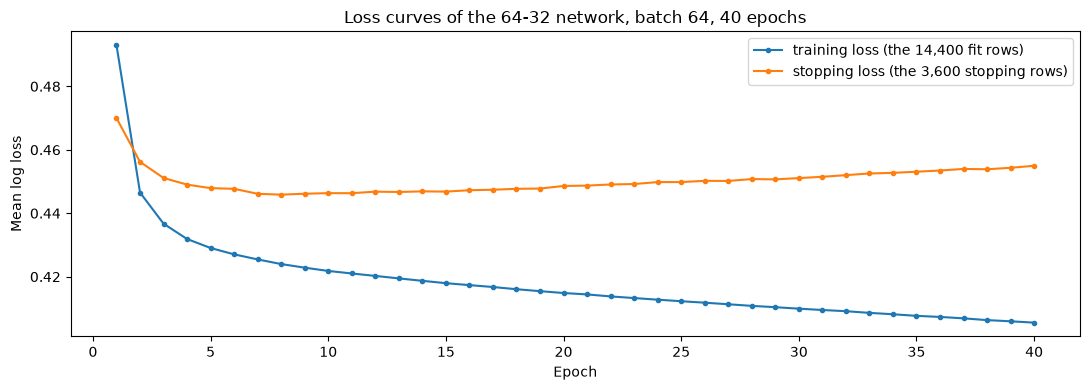

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(table_40.index, table_40["loss"], marker=".", label="training loss (the 14,400 fit rows)")
ax.plot(table_40.index, table_40["val_loss"], marker=".", label="stopping loss (the 3,600 stopping rows)")
ax.set_title("Loss curves of the 64-32 network, batch 64, 40 epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean log loss")
ax.legend()
plt.tight_layout()
plt.show()

* The training loss falls in every one of the 40 epochs, from 0.4930 to 0.4055. The stopping loss falls for a few epochs, flattens, and then climbs: from 0.4700 at epoch 1 to 0.4459 at its lowest, then up to 0.4550 at epoch 40. The gap between the two curves keeps widening.
* After the turn, the network is still lowering its loss on the rows it fits, but it is now fitting details of those 14,400 rows that do not hold on rows it has not seen. Section 4.4 finds the turn by function, and section 4.6 names the pattern.

## 4.3 Batch Size at a Fixed Number of Epochs

The batch size decides how many rows each step's gradient is worked out from, and so how many steps an epoch takes. Fix the epochs at 20 and change only the batch size: 32 and 256 against section 4.2's 64.

A run of `fit` for 20 epochs at batch 64 is exactly the first 20 epochs of section 4.2's run: the seed fixes the starting weights and the order the batches come in, so there is no need to fit it again. (The builder of this notebook fitted it again and checked that every loss is the same.)

Q. Fit at batch 32 and at batch 256 for 20 epochs, read batch 64 from section 4.2, and compare the three on the stopping rows.

In [21]:
# one setting changes, the batch size; the network, the seed, the rows, and the 20 epochs stay the same
tables = {}
for batch_size in [32, 256]:
    model = build_network()
    history = model.fit(A_fit, y_fit_32, validation_data=(A_stop, y_stop_32), epochs=20, batch_size=batch_size,
                        verbose=0)
    tables[batch_size] = netkit.history_table(history)
# batch 64: the first 20 epochs of section 4.2's run
tables[64] = table_40.loc[:20]

rows = []
for batch_size in [32, 64, 256]:
    table = tables[batch_size]
    steps = netkit.steps_per_epoch(len(A_fit), batch_size)
    rows.append({"batch": batch_size, "steps per epoch": steps, "steps in all": steps * 20,
                 "training loss, epoch 20": table["loss"].iloc[-1],
                 "stopping loss, epoch 20": table["val_loss"].iloc[-1],
                 # idxmin gives the first epoch with the smallest stopping loss
                 "lowest stopping loss": table["val_loss"].min(), "at epoch": table["val_loss"].idxmin()})
batch_table = pd.DataFrame(rows).set_index("batch")
print(batch_table.round(4).to_string())

       steps per epoch  steps in all  training loss, epoch 20  stopping loss, epoch 20  lowest stopping loss  at epoch
batch                                                                                                                 
32                 450          9000                   0.4134                   0.4478                0.4440         5
64                 225          4500                   0.4149                   0.4486                0.4459         8
256                 57          1140                   0.4187                   0.4434                0.4432        17


* After 20 epochs, the smaller the batch, the lower the training loss: 0.4134 at batch 32, 0.4149 at 64, 0.4187 at 256. Batch 32 took 9,000 steps and batch 256 only 1,140, so batch 32 had far more steps in which to fit its rows.
* On the stopping rows the order turns around at epoch 20: batch 256 is lowest (0.4434), and batch 32 is above it (0.4478). Each batch size reached its lowest stopping loss at a different epoch: batch 32 at epoch 5, batch 64 at 8, batch 256 at 17. By epoch 20 the small batches were well past their turn and the large one had only just reached it.
* So comparing batch sizes at one fixed number of epochs compares networks at different points of their curves. The fairer number is each one's **lowest** stopping loss: 0.4440, 0.4459, and 0.4432, within 0.0026 of each other. Section 4.8 asks whether a difference that size means anything.
* One setting changed from section 4.2: the batch size, 64 to 32 and to 256; compared on the 3,600 stopping rows.

Q. Draw the three stopping-loss curves.

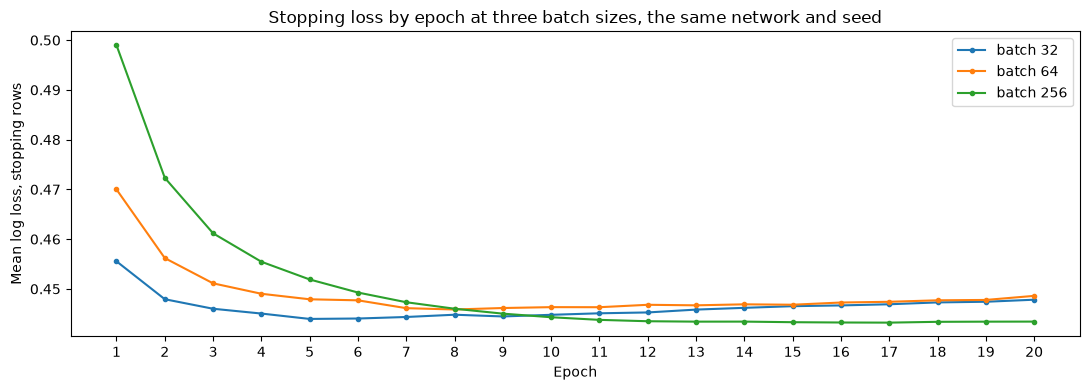

In [22]:
fig, ax = plt.subplots(figsize=(11, 4))
for batch_size in [32, 64, 256]:
    ax.plot(tables[batch_size].index, tables[batch_size]["val_loss"], marker=".", label=f"batch {batch_size}")
ax.set_title("Stopping loss by epoch at three batch sizes, the same network and seed")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean log loss, stopping rows")
ax.set_xticks(range(1, 21))
ax.legend()
plt.tight_layout()
plt.show()

* Batch 32 drops fastest and turns first. Batch 256 starts highest, because after one epoch it has taken only 57 steps, and reaches its turn only near epoch 20. Per epoch, a smaller batch does more fitting.

**Leaving the course's size on purpose.** The next cell fits the same network at batch 1,024 and at the full 14,400 rows, again for 20 epochs. It is the one cell in this course that goes past the size the course keeps its networks to. A step at these batch sizes multiplies a large block of rows by each layer's weights, and when TensorFlow is left free to use every core of the machine it splits that work across the cores and adds the parts up in a different order. Sums of float32 numbers added in a different order differ in the last digits, so this cell's losses can differ in the third or fourth decimal from one machine to another, and even between two runs on one thread. The cell therefore prints its losses to 3 decimals, and its first line marks it: when the course checks this notebook, every other cell must print exactly the same text on one thread and on every core, and this cell alone may differ by up to 0.005 in its decimals. No later cell uses anything from these two networks.

In [23]:
# thread tolerance: large batches differ in the last digits across thread counts
# batch 1,024 and the full batch, the same network and 20 epochs; losses to 3 decimals (see the note above)
for batch_size in [1024, len(A_fit)]:
    model = build_network()
    history = model.fit(A_fit, y_fit_32, validation_data=(A_stop, y_stop_32), epochs=20, batch_size=batch_size,
                        verbose=0)
    steps = netkit.steps_per_epoch(len(A_fit), batch_size)
    print(f"batch {batch_size:,}: steps per epoch {steps}, {steps * 20} in all; "
          f"epoch 20 training loss {history.history['loss'][-1]:.3f}, stopping loss {history.history['val_loss'][-1]:.3f}")

batch 1,024: steps per epoch 15, 300 in all; epoch 20 training loss 0.430, stopping loss 0.446


batch 14,400: steps per epoch 1, 20 in all; epoch 20 training loss 0.534, stopping loss 0.532


* Batch 1,024 takes 15 steps an epoch, 300 in all, and its losses are still falling at epoch 20: it has not reached its turn. The full batch takes one step an epoch, 20 steps in all, and both its losses are far above every other run's: 20 full-batch steps at Adam's learning rate of 0.001 move the weights only a short way from where they started. Day 1's full-batch descent on one weight took 100 steps at a learning rate of 1.
* Larger batches take fewer steps per epoch, so at the same number of epochs they move the weights less. A large batch is not wrong; it needs more epochs, or a larger learning rate (day 7). Small batches move further per epoch, and turn sooner.

## 4.4 Epochs, and the Best Epoch

The number of epochs is a setting like the batch size, and section 4.2's curves show how to choose it: keep the epoch where the stopping loss is smallest. The training loss is no guide, because it keeps falling for as long as you fit.

Q. Add `best_epoch` to `netkit.py`, and its three tests.

In [24]:
%%writefile -a netkit.py


def best_epoch(history, monitor: str = "val_loss") -> int:
    """The epoch with the smallest value of monitor, counted from 1.

    Inputs: history, the object model.fit returns; monitor, the recorded value to read.
    Output: the first epoch (from 1) at which monitor is smallest; on a tie the earlier epoch.
    Convention: the stopping rule reads the stopping rows' loss (val_loss), never the training loss, which keeps
    falling as the network fits its own rows more closely.
    Excel: =MATCH(MIN(C2:C41),C2:C41,0) on a pasted loss column.
    Raises ValueError if monitor is not recorded.
    """
    if monitor not in history.history:
        raise ValueError(f"{monitor!r} is not recorded; recorded: {sorted(history.history)}")
    # argmin returns the first position of the smallest value
    return int(np.argmin(history.history[monitor])) + 1

Appending to netkit.py


In [25]:
%%writefile -a test_netkit.py


def test_best_epoch_reads_val_loss():
    # the training loss keeps falling; the stopping loss is smallest at epoch 3
    history = RecordedHistory({"loss": [0.6, 0.5, 0.4, 0.3, 0.2], "val_loss": [0.65, 0.6, 0.55, 0.58, 0.62]})
    assert netkit.best_epoch(history) == 3
    assert netkit.best_epoch(history, monitor="loss") == 5


def test_best_epoch_first_on_tie():
    history = RecordedHistory({"val_loss": [0.7, 0.5, 0.6, 0.5]})
    assert netkit.best_epoch(history) == 2


def test_best_epoch_rejects_missing_monitor():
    with pytest.raises(ValueError):
        netkit.best_epoch(RecordedHistory({"loss": [0.5]}))

Appending to test_netkit.py


* `np.argmin` returns the **first** position of the smallest value, so on a tie the earlier epoch wins, and adding 1 turns a position into an epoch. The docstring says the stopping rule reads the stopping rows' loss, never the training loss; `monitor="loss"` is allowed so you can see the difference.
* `test_best_epoch_reads_val_loss` hands the function a curve whose answer is known: a training loss falling for five epochs and a stopping loss lowest at epoch 3.

Q. Reload and run all of today's tests.

In [26]:
importlib.reload(netkit)
print(f"best_epoch in netkit: {hasattr(netkit, 'best_epoch')}")

best_epoch in netkit: True


In [27]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_netkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

....................                                                     [100%]
20 passed in 10.38s



* `20 passed`: the module's day 4 functions, tested.

Q. Which epoch of section 4.2's run has the smallest stopping loss, and what happened to each loss after it?

In [28]:
best = netkit.best_epoch(history_40)
print(f"best epoch on the stopping loss: {best} of {len(table_40)}")
print(f"stopping loss: {table_40.loc[best, 'val_loss']:.4f} at epoch {best}, {table_40['val_loss'].iloc[-1]:.4f} at epoch {len(table_40)}")
print(f"training loss: {table_40.loc[best, 'loss']:.4f} at epoch {best}, {table_40['loss'].iloc[-1]:.4f} at epoch {len(table_40)}")
print(f"the training loss fell in every epoch: {bool((table_40['loss'].diff().dropna() < 0).all())}")
print(f"best epoch on the training loss, for comparison: {netkit.best_epoch(history_40, monitor='loss')}")

best epoch on the stopping loss: 8 of 40
stopping loss: 0.4459 at epoch 8, 0.4550 at epoch 40
training loss: 0.4240 at epoch 8, 0.4055 at epoch 40
the training loss fell in every epoch: True
best epoch on the training loss, for comparison: 40


* Epoch 8. After it, the stopping loss rose from 0.4459 to 0.4550 while the training loss went on falling, from 0.4240 to 0.4055: the 32 epochs after epoch 8 made the network better on its own rows and worse on rows it never fits.
* Read from the training loss, the "best" epoch is 40, the last one, and it would be the last one however many epochs you ran. That is the AI check at the end of today.

## 4.5 Early Stopping

Section 4.4 found the best epoch after fitting 40 epochs and throwing away the last 32. **Early stopping** finds it while fitting. Keras's `EarlyStopping` callback (a callback is an object `fit` hands the record to at the end of each epoch) watches a recorded value and stops `fit` when that value has not improved for `patience` epochs in a row; with `restore_best_weights=True` it then puts back the weights from the best epoch. Course 5 day 8 stopped XGBoost's trees the same way, on rows carved by `early_stopping_rows`.

Q. Fit the same network with `EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)`, allowing up to 200 epochs.

In [29]:
# stop once the stopping loss has not improved for 10 epochs in a row, and keep the best epoch's weights
stopper = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
model_stopped = build_network()
history_stopped = model_stopped.fit(A_fit, y_fit_32, validation_data=(A_stop, y_stop_32), epochs=200, batch_size=64,
                                    callbacks=[stopper], verbose=0)
epochs_run = len(history_stopped.history["loss"])
print(f"epochs run: {epochs_run} of 200")
# EarlyStopping records the epoch it kept in best_epoch, counted from 0
print(f"best epoch: netkit.best_epoch {netkit.best_epoch(history_stopped)}, EarlyStopping's best_epoch + 1 {stopper.best_epoch + 1}")

# the weights the model holds now, scored on the stopping rows, against the smallest stopping loss in the record
kept_loss = model_stopped.evaluate(A_stop, y_stop_32, verbose=0)
smallest = min(history_stopped.history["val_loss"])
print(f"stopping loss of the weights kept: {kept_loss:.4f}; smallest in the record: {smallest:.4f}")
print(f"equal within 1e-6: {abs(kept_loss - smallest) < 1e-6}")
same = np.array_equal(history_stopped.history["val_loss"], history_40.history["val_loss"][:epochs_run])
print(f"the same stopping losses as section 4.2's first {epochs_run} epochs: {same}")

epochs run: 18 of 200
best epoch: netkit.best_epoch 8, EarlyStopping's best_epoch + 1 8


stopping loss of the weights kept: 0.4459; smallest in the record: 0.4459
equal within 1e-6: True
the same stopping losses as section 4.2's first 18 epochs: True


* The best epoch was 8; `fit` waited 10 more epochs for an improvement that did not come and stopped after epoch 18, then restored epoch 8's weights. `evaluate` on the stopping rows gives the smallest loss in the record, so the model really holds the best epoch's weights, not the last epoch's.
* The run is section 4.2's run up to the point it stopped, epoch for epoch, because the seed and the rows are the same. Early stopping changed when the fitting ended, nothing else.
* `EarlyStopping`'s own record of the epoch it kept, `best_epoch`, counts from 0 (read in Keras 3.15.1's source file `keras/src/callbacks/early_stopping.py`), so it is 7, and `netkit.best_epoch` counts from 1. Both name the same epoch.

Q. Score both networks once on the validation rows: section 4.2's network after all 40 epochs, and the early-stopped one.

In [30]:
# the model probability of default in this file, for each validation account
outputs = {"64-32, 40 epochs": model_40.predict(A_valid, verbose=0).ravel(),
           "64-32, early stopping": model_stopped.predict(A_valid, verbose=0).ravel()}
for name, output in outputs.items():
    print(f"{name}: validation ROC AUC {roc_auc_score(y_valid, output):.4f}, "
          f"average precision {average_precision_score(y_valid, output):.4f}, "
          f"mean log loss {netkit.mean_log_loss(y_valid, output):.4f}")

64-32, 40 epochs: validation ROC AUC 0.7689, average precision 0.5291, mean log loss 0.4460
64-32, early stopping: validation ROC AUC 0.7689, average precision 0.5258, mean log loss 0.4430


* The two rank the validation accounts almost the same: ROC AUC 0.7689 after 40 epochs and 0.7689 with early stopping. Average precision is a little higher for the 40-epoch network (0.5291 against 0.5258).
* Where the extra epochs show is the log loss: 0.4460 after 40 epochs against 0.4430 with early stopping. The stopping loss is a log loss, and on new rows the network fitted past its best epoch is worse on exactly that measure: its outputs have grown more confident than the rows support, while the order it puts the accounts in has hardly changed.
* These are the two validation scores of the day's networks, reported once each; nothing was chosen on them. The best epoch was chosen on the 3,600 stopping rows.
* One setting changed from section 4.2: the number of epochs, 40 to 8 chosen by early stopping; chosen on the 3,600 stopping rows.

## 4.6 Reading a Curve: Underfit, Fit, Overfit

Every loss curve in this course is read the same way, by three patterns.

* **Underfit:** both losses are still falling, or have flattened at a level a more flexible network gets below, and they sit close together. The network has not fitted what the rows hold.
* **Fit:** the stopping loss is at its lowest. This is the epoch early stopping keeps.
* **Overfit:** the training loss keeps falling while the stopping loss rises, and the gap between them widens. The network is fitting its own rows' details.

A network too small for the rows underfits however long it runs. Day 2's single neuron is the smallest there is, so fit it for 20 epochs and set it beside the two runs above.

Q. Fit one neuron on the same rows for 20 epochs at batch 64.

In [31]:
# seed before building any Keras model, so its numbers never depend on what ran before
keras.utils.set_random_seed(SEED)
neuron = keras.Sequential([keras.Input(shape=(A_fit.shape[1],)),
                           keras.layers.Dense(1, activation="sigmoid", name="neuron")], name="one_neuron")
neuron.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
history_neuron = neuron.fit(A_fit, y_fit_32, validation_data=(A_stop, y_stop_32), epochs=20, batch_size=64,
                            verbose=0)

# the three runs side by side
runs = {"one neuron, 20 epochs": history_neuron, "early stopping": history_stopped, "40 epochs": history_40}
summary = []
for name, history in runs.items():
    table = netkit.history_table(history)
    summary.append({"run": name, "epochs run": len(table), "best epoch": netkit.best_epoch(history),
                    "lowest stopping loss": table["val_loss"].min(), "last training loss": table["loss"].iloc[-1],
                    "last stopping loss": table["val_loss"].iloc[-1]})
print(pd.DataFrame(summary).set_index("run").round(4).to_string())

                       epochs run  best epoch  lowest stopping loss  last training loss  last stopping loss
run                                                                                                        
one neuron, 20 epochs          20          20                0.4702              0.4621              0.4702
early stopping                 18           8                0.4459              0.4161              0.4477
40 epochs                      40           8                0.4459              0.4055              0.4550


Q. Draw the three, one panel each.

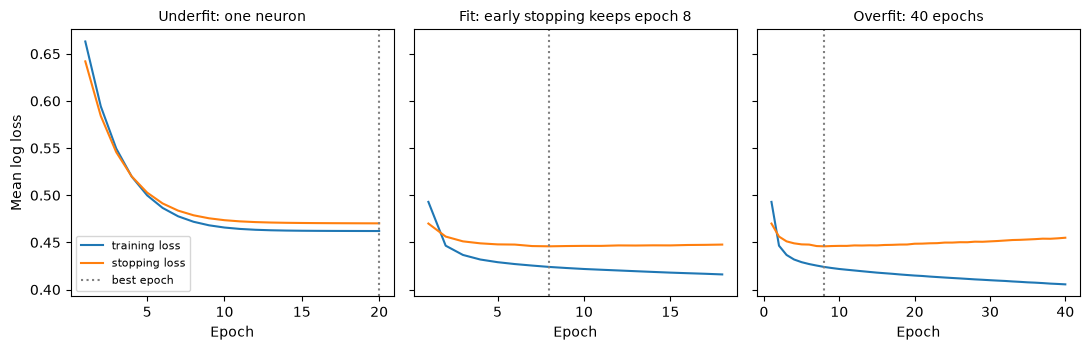

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
titles = ["Underfit: one neuron", "Fit: early stopping keeps epoch 8", "Overfit: 40 epochs"]
for ax, (name, history), title in zip(axes, runs.items(), titles):
    table = netkit.history_table(history)
    ax.plot(table.index, table["loss"], label="training loss")
    ax.plot(table.index, table["val_loss"], label="stopping loss")
    ax.axvline(netkit.best_epoch(history), color="grey", linestyle=":", label="best epoch")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Epoch")
axes[0].set_ylabel("Mean log loss")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

* **Underfit.** The neuron's two losses are 0.4621 and 0.4702 at epoch 20, close together and both still falling (its best epoch is its last). Its lowest stopping loss, 0.4702, is above the network's 0.4459: more epochs would lower it a little, but a single neuron cannot fit what two hidden layers fit.
* **Fit.** The early-stopped run holds the weights of epoch 8, the bottom of its stopping curve.
* **Overfit.** After epoch 8 the 40-epoch run's training loss kept falling and its stopping loss kept rising; the gap went from 0.0219 at epoch 8 to 0.0494 at epoch 40.
* A curve is read on the stopping rows. The training loss alone looks like steady progress in all three panels.

## 4.7 Where a GPU Would Help

Day 1 answered which devices TensorFlow uses here. Its paragraph, word for word:

**Devices.** TensorFlow runs a network on the devices it can use: the CPU always, and a GPU (a graphics card) where it supports one. On native Windows it supports none, and it says so itself the first time anything lists the devices: "TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin." (source: `tensorflow/python/framework/config.py` in TensorFlow 2.21.0, read for this course on 2026-10-06). The setup cell turns TensorFlow's own notices down to errors, which hides that one; this paragraph is what it says. The course uses neither of the two routes it names.

Colab is the other route to a GPU. Its FAQ says Colab "provides free of charge access to computing resources, including GPUs and TPUs", and that "Colab resources are not guaranteed and not unlimited, and usage limits sometimes fluctuate." The setting is under Runtime, then Change Runtime Type, then Hardware Accelerator; the FAQ names it where it says how to turn an accelerator off: "Choose Runtime > Change Runtime Type and set Hardware Accelerator to None" (source: Colab's FAQ, https://research.google.com/colaboratory/faq.html, read 2026-10-06). Nothing in this course needs a GPU. Every notebook runs on the CPU within its time budget, and nothing here was run or timed on a GPU. Day 4 says where a GPU would help.

**Where a GPU would help.** A GPU is built to do a great many multiplications at the same time. A step of a network is mostly multiplications: each batch of rows is multiplied by each layer's weights. So a GPU helps where those products are large, which means large batches through wide layers, and many of them. This course's networks are the other kind: on the card file, 19 inputs, hidden layers of 64 units or fewer, and batches of 256 rows or fewer outside today's one marked cell. Each step is a small product, and the CPU fits every notebook inside its time budget. If you open a notebook in Colab, the switch is under Runtime, then Change Runtime Type, as day 1 said; no notebook in this course needs it, and none was run or timed on a GPU, so nothing here says how much faster one would be.

Q. Which devices did today's networks run on?

In [33]:
# every kind of device TensorFlow can use here, and the GPUs among them
print(f"device kinds: {sorted({device.device_type for device in tf.config.list_physical_devices()})}")
print(f"GPUs TensorFlow can use here: {len(tf.config.list_physical_devices('GPU'))}")

device kinds: ['CPU']
GPUs TensorFlow can use here: 0


* The CPU only, as on day 1. Every number today came from it.

## 4.8 Seeds: How Much Moves with the Seed Alone

Every network today was built after `keras.utils.set_random_seed(SEED)`, so every rerun gives the same digits. But the seed is a choice too: it sets the starting weights and the order the batches come in. Another seed gives another network, fitted the same way on the same rows, and its numbers differ for no reason but the seed. Before any later day compares two settings, you need to know how big that difference is.

Q. Fit section 4.5's network with early stopping under five seeds, `SEED + 0` to `SEED + 4`, and record the best epoch, the lowest stopping loss, and the validation ROC AUC of each.

In [34]:
# seeds: the only line that changes is the seed, SEED + k for k = 0 to 4; SEED + 0 is section 4.5's run
seed_rows = []
for k in range(5):
    if k == 0:
        # SEED + 0 is section 4.5's run: reuse it rather than fit it again
        model_k, history_k = model_stopped, history_stopped
    else:
        keras.utils.set_random_seed(SEED + k)
        model_k = keras.Sequential([keras.Input(shape=(A_fit.shape[1],)),
                                    keras.layers.Dense(64, activation="relu", name="hidden_1"),
                                    keras.layers.Dense(32, activation="relu", name="hidden_2"),
                                    keras.layers.Dense(1, activation="sigmoid", name="output")], name=f"dense_64_32_seed_{k}")
        model_k.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
        stopper_k = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
        history_k = model_k.fit(A_fit, y_fit_32, validation_data=(A_stop, y_stop_32), epochs=200, batch_size=64,
                                callbacks=[stopper_k], verbose=0)
    seed_rows.append({"seed": f"SEED + {k}", "best epoch": netkit.best_epoch(history_k),
                      "epochs run": len(history_k.history["loss"]),
                      "lowest stopping loss": min(history_k.history["val_loss"]),
                      "validation ROC AUC": roc_auc_score(y_valid, model_k.predict(A_valid, verbose=0).ravel())})
seed_table = pd.DataFrame(seed_rows).set_index("seed")
print(seed_table.round(4).to_string())
for column in ["lowest stopping loss", "validation ROC AUC"]:
    values = seed_table[column]
    print(f"{column}: range {values.max() - values.min():.4f}, standard deviation {values.std(ddof=0):.4f}")

          best epoch  epochs run  lowest stopping loss  validation ROC AUC
seed                                                                      
SEED + 0           8          18                0.4459              0.7689
SEED + 1          13          23                0.4471              0.7697
SEED + 2          12          22                0.4440              0.7701
SEED + 3          11          21                0.4486              0.7696
SEED + 4           8          18                0.4462              0.7712
lowest stopping loss: range 0.0046, standard deviation 0.0015
validation ROC AUC: range 0.0023, standard deviation 0.0007


* `SEED + 0` is section 4.5's run, reused rather than fitted again (the builder of this notebook fitted it again under `SEED + 0`, and every number matched). The five seeds kept epochs 8, 13, 12, 11, and 8, with lowest stopping losses spread over 0.0046 (standard deviation 0.0015) and validation ROC AUC over 0.0023 (standard deviation 0.0007).
* That is the yardstick. Section 4.3's three batch sizes had lowest stopping losses within 0.0026 of each other, less than the 0.0046 the seed alone moves this network. So on these rows the batch sizes 32, 64, and 256 cannot be told apart by their lowest stopping loss: the difference is the size of a change of seed. Every later comparison in this course is read against a spread like this one.
* The validation ROC AUC of five seeds is reported to measure the spread, not to pick a seed. Choosing the best-looking seed on the validation rows would be choosing on the rows that report.
* One setting changed from section 4.5: the seed, SEED + 0 to SEED + 4; compared on the 3,600 stopping rows.

## Excel Side by Side

Excel has no network training: no mini-batches, no seeded shuffle, no epochs, and no early stopping, so nothing in it can produce a loss curve. What it can do is read one. Paste the 40 epochs of section 4.2's record into a sheet and every question this notebook asked of the curve is a formula. Each formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-06), with the epoch in column A, the training loss in B2:B41, and the stopping loss in C2:C41 of a sheet named `losses`; Excel refused the name `History`, which it keeps for itself.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Steps per epoch at batch 64 | `netkit.steps_per_epoch(14_400, 64)` | `=ROUNDUP(14400/64,0)` | 225 (tested by the course's foundation check) |
| Steps per epoch, batch size in F2 | `netkit.steps_per_epoch(n_fit, batch_size)` | `=ROUNDUP(14400/F2,0)`, filled down | 450, 225, 113, 57, 15, 1 for batches 32, 64, 128, 256, 1,024, 14,400 |
| The best epoch | `netkit.best_epoch(history_40)` | `=MATCH(MIN(C2:C41),C2:C41,0)` | 8 |
| The lowest stopping loss | `table_40["val_loss"].min()` | `=MIN(C2:C41)` | 0.445864 |
| The "best" epoch on the training loss | `netkit.best_epoch(history_40, monitor="loss")` | `=MATCH(MIN(B2:B41),B2:B41,0)` | 40 |
| The gap between the curves | `table_40["val_loss"] - table_40["loss"]` | `=C2-B2` in D2, filled down | 0.021882 at epoch 8 |

**Steps per epoch is ROUNDUP.** `ROUNDUP(14400/64,0)` rounds 225 exactly to 225 and 14,401 rows' 225.02 up to 226, as `math.ceil` does. Put the batch sizes in a column and fill the formula down to get the table of section 4.1.

**The best epoch is MATCH of MIN.** `MIN(C2:C41)` finds the lowest stopping loss, and `MATCH(...,C2:C41,0)` returns its position in the column, counted from 1: the epoch. With match type `0` MATCH finds only an exact value (`=ISNA(MATCH(0.55,K2:K5,0))` returned TRUE on the check's hand column 0.7, 0.5, 0.6, 0.5), and on a tie it returns the first: `=MATCH(MIN(K2:K5),K2:K5,0)` on that column returned 2, so the earlier epoch wins, the same rule as `np.argmin` and `test_best_epoch_first_on_tie`. Point the same formula at the training loss in column B and it returns 40, the last epoch: the AI check's mistake, in a cell.

**The gap is a subtraction filled down.** `=C2-B2` beside the record shows the stopping loss pulling away from the training loss after epoch 8; it is exercise 3's `curve_gap`, cell by cell.

Q. Do Excel's numbers equal Python's?

In [35]:
# Excel's numbers, from the course's Excel check, beside Python's for the same record
excel = {"best epoch": 8,
         "lowest stopping loss": 0.4458635151386261,
         "best epoch on the training loss": 40,
         "gap at the best epoch": 0.02188199758529663,
         "steps per epoch, batch 256": 57}
python = {"best epoch": netkit.best_epoch(history_40),
          "lowest stopping loss": table_40["val_loss"].min(),
          "best epoch on the training loss": netkit.best_epoch(history_40, monitor="loss"),
          "gap at the best epoch": table_40.loc[netkit.best_epoch(history_40), "val_loss"] - table_40.loc[netkit.best_epoch(history_40), "loss"],
          "steps per epoch, batch 256": netkit.steps_per_epoch(len(A_fit), 256)}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
print(side_by_side.round(6).to_string())

                                     Excel     Python  within 1e-12
best epoch                        8.000000   8.000000          True
lowest stopping loss              0.445864   0.445864          True
best epoch on the training loss  40.000000  40.000000          True
gap at the best epoch             0.021882   0.021882          True
steps per epoch, batch 256       57.000000  57.000000          True


* Every number matches. The losses were pasted from the record, so Excel and Python read the same numbers; what the comparison shows is that MATCH of MIN, the subtraction, and ROUNDUP do the same jobs as `best_epoch`, `curve_gap`, and `steps_per_epoch`.

## Save the Day with Git

The work folder gets its repository, the day's two module files are committed, and the experiment log gets two commits: the network after a fixed 40 epochs, then the same network with early stopping. Today's Git step reads the log as it stood one commit back.

Q. Make the work folder a repository.

In [36]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [37]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course6_04_h9hrqtqx and nowhere else


Q. Ignore Python's and pytest's caches, Excel workbooks, and saved Keras models, then commit the modules.

In [38]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
*.keras

Writing .gitignore


In [39]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py netkit.py test_netkit.py
!git -C "{work}" commit -q -m "netkit day 4: steps per epoch, the loss history as a table, the best epoch; 20 tests"
!git -C "{work}" log --oneline

dfa6217 netkit day 4: steps per epoch, the loss history as a table, the best epoch; 20 tests


Q. Start `results.csv` with the 40-epoch network's validation metrics at threshold 0.5, and commit it.

In [40]:
def results_row(name, output):
    """One row of the experiment log: validation metrics, and flags at threshold 0.5."""
    metrics = mlkit.classification_metrics(y_valid, (output >= 0.5).astype(int))
    return {"model": name, "rows": "validation", "roc_auc": roc_auc_score(y_valid, output),
            "average_precision": average_precision_score(y_valid, output), "threshold": 0.5, **metrics}


results = pd.DataFrame([results_row("dense_64_32_40_epochs", outputs["64-32, 40 epochs"])])
# 4 decimals and LF line endings, so a later diff shows a real change and prints the same everywhere
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
dense_64_32_40_epochs,validation,0.7689,0.5291,0.5000,0.8193,0.6431,0.4115,0.5018



In [41]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the 64-32 network after a fixed 40 epochs, on the validation rows"

Q. Add the early-stopped network's row, commit, and then show `results.csv` as it stood one commit back.

In [42]:
results = pd.DataFrame([results_row("dense_64_32_40_epochs", outputs["64-32, 40 epochs"]),
                        results_row("dense_64_32_early_stopping", outputs["64-32, early stopping"])])
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))
print(f"accuracy of flagging no account (all-zero baseline) on the validation rows: {1 - y_valid.mean():.4f}")

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
dense_64_32_40_epochs,validation,0.7689,0.5291,0.5000,0.8193,0.6431,0.4115,0.5018
dense_64_32_early_stopping,validation,0.7689,0.5258,0.5000,0.8203,0.6547,0.3971,0.4944

accuracy of flagging no account (all-zero baseline) on the validation rows: 0.7788


In [43]:
# HEAD~1 is the commit before the last one; HEAD~1:results.csv is the file as it stood there
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the same network with early stopping on the stopping rows"
!git -C "{work}" log --oneline
!git -C "{work}" show HEAD~1:results.csv

2129da6 Experiment log: the same network with early stopping on the stopping rows
c74f0eb Experiment log: the 64-32 network after a fixed 40 epochs, on the validation rows
dfa6217 netkit day 4: steps per epoch, the loss history as a table, the best epoch; 20 tests


model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
dense_64_32_40_epochs,validation,0.7689,0.5291,0.5000,0.8193,0.6431,0.4115,0.5018


* `git show HEAD~1:results.csv` prints the file as it was one commit ago, with only the 40-epoch row, without changing anything in the folder. `HEAD` is the last commit, `HEAD~1` the one before it, `HEAD~2` the one before that. It is the quick way to see an old result without checking out an old commit.
* At threshold 0.5 the early-stopped network has accuracy 0.8203 and recall 0.3971, against the all-zero baseline's accuracy of 0.7788. The threshold stays at 0.5 until day 5 chooses one from out-of-fold outputs on the training rows.

## Bring It Home

Add today's three functions to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open both files.

```powershell
Set-Location "$HOME\projects\python-fixed-income"
.\.venv\Scripts\Activate.ps1
Set-Location "$HOME\projects\my_bondmath"
code netkit.py
code test_netkit.py
```

**Step 2.** Paste the code of today's three `%%writefile -a netkit.py` cells (sections 4.1, 4.2, and 4.4), without their first lines, at the end of `netkit.py`, one after the other. Do the same at the end of `test_netkit.py` with the three `%%writefile -a test_netkit.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_netkit.py
```

The last line says `20 passed`.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add netkit.py test_netkit.py
git commit -m "netkit day 4: steps per epoch, the loss history as a table, the best epoch; 20 tests"
git log --oneline -3
```

**Step 5.** If you keep a `results.csv` in the folder, look at an earlier version of it without checking anything out: `git show HEAD~1:results.csv`.

## You Can Now

* Say what an epoch, a batch, and a step are, and count the steps with `steps_per_epoch`.
* Turn the record of a run of `fit` into a table with `history_table`, and draw the training and stopping loss curves.
* Say what the batch size does at a fixed number of epochs, and why each batch size has to be compared at its own best epoch.
* Find the best epoch on the stopping loss with `best_epoch`, and say why the training loss cannot pick it.
* Fit with `EarlyStopping` and check that the model holds the best epoch's weights.
* Read a pair of loss curves as underfit, fit, or overfit.
* Say where a GPU would help, and why this course runs on the CPU.
* Measure the seed spread of a network, and read a comparison against it.
* Show an earlier version of a file with `git show HEAD~1:results.csv`.

Next, day 5: the case study. `dense_classifier` builds the network in netkit, `cv_network` gives out-of-fold outputs and a threshold for recall 0.70 on the training rows, and the first network goes beside Course 4's logistic regression and Course 5's LightGBM on the validation rows, with intervals.

## Exercises

The exercises use the card rows as the lesson does: 14,400 rows to fit and 3,600 to stop on, carved from Course 4's 18,000 training rows; the test rows are closed and the four person columns are not features. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads and scales the rows as in section 4.2, defines `build_network`, uses section 4.5's early-stopped network (`history_stopped` and `stopper`), and defines `check`, a small function that marks your answers.

In [44]:
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")
# Course 4's split, rebuilt by Course 5's function: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
# the four columns that describe people are never features: stop if one slips in
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"
# a stratified fifth of the training rows to stop on (Course 5's function), the rest to fit
X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
# the scaler is fitted on the fit rows only; the stopping and validation rows are only transformed with it
scaler, A_fit, A_stop, A_valid = netkit.fit_arrays(StandardScaler(), X_fit, X_stop, X_valid)
y_fit_32, y_stop_32 = y_fit.to_numpy("float32"), y_stop.to_numpy("float32")


def build_network():
    """The course's default card network: 64 and 32 ReLU units, a sigmoid output, Adam at 1e-3, log loss."""
    # seed before building any Keras model, so its numbers never depend on what ran before
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([keras.Input(shape=(A_fit.shape[1],)),
                              keras.layers.Dense(64, activation="relu", name="hidden_1"),
                              keras.layers.Dense(32, activation="relu", name="hidden_2"),
                              keras.layers.Dense(1, activation="sigmoid", name="output")], name="dense_64_32")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return model


# section 4.5's run is still in memory: history_stopped and stopper (after a restart, run section 4.5 first)
print(f"section 4.5's run: {len(history_stopped.history['loss'])} epochs run, best epoch {netkit.best_epoch(history_stopped)}")


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

section 4.5's run: 18 epochs run, best epoch 8


### Exercise 1

Q. Fit `build_network()` for 20 epochs at batch 16, with the stopping rows as `validation_data`. How many steps per epoch does it take, at which epoch is its stopping loss lowest, and where does its lowest stopping loss sit beside section 4.3's three batches and section 4.8's seed spread? Store its stopping loss at epoch 20 in **ex1_stop_loss**.

In [45]:
ex1_stop_loss = ...

In [46]:
check("Exercise 1 stopping loss at batch 16", ex1_stop_loss, 0.44558748602867126)

Exercise 1 stopping loss at batch 16: not attempted yet


### Exercise 2

Q. Fit `build_network()` with early stopping twice more, with `patience=3` and with `patience=20` (up to 200 epochs at batch 64 each time). How many epochs does each run, and which epoch does each keep? Store the epochs run in **ex2_run_3** and **ex2_run_20**.

In [47]:
ex2_run_3 = ...
ex2_run_20 = ...

In [48]:
check("Exercise 2 epochs run at patience 3", ex2_run_3, 11)
check("Exercise 2 epochs run at patience 20", ex2_run_20, 28)

Exercise 2 epochs run at patience 3: not attempted yet
Exercise 2 epochs run at patience 20: not attempted yet


### Exercise 3

Q. Add a function to your module. `curve_gap(history)` returns the stopping loss minus the training loss, epoch by epoch, as a Series named `gap` indexed `epoch` from 1, and refuses a history without `loss` or `val_loss` with `ValueError`. Build it on `history_table`, and write the docstring first. Then add `test_curve_gap_hand`, which uses `RecordedHistory` to check a three-epoch curve by hand, the index, and the refusal. Run pytest, reload the module, and store the gap of `history_stopped` at its best epoch in **ex3_gap_best**.

Write the function in the cell that starts with `%%writefile -a netkit.py` and the test in the one that starts with `%%writefile -a test_netkit.py`, and run each of those cells once.

In [49]:
%%writefile -a netkit.py


# Exercise 3: write curve_gap(history) below this line

Appending to netkit.py


In [50]:
%%writefile -a test_netkit.py


# Exercise 3: write test_curve_gap_hand() below this line

Appending to test_netkit.py


In [51]:
# run pytest, reload the module, then run your function
ex3_gap_best = ...

In [52]:
check("Exercise 3 the gap at the best epoch", ex3_gap_best, 0.02188199758529663)

Exercise 3 the gap at the best epoch: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that gives the epoch the stopping rule keeps, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The epoch the stopping rule keeps: the epoch, counted from 1, with the smallest loss on the stopping rows.

    Input: history, the object model.fit returns when the stopping rows are passed as validation_data.
    Output: a whole number from 1 to the number of epochs run, the same epoch that
    EarlyStopping(monitor="val_loss", restore_best_weights=True) restores.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a whole number between 1 and the epochs run, and contains one bug.

In [53]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def stopping_epoch(history):
    """The epoch the stopping rule keeps: the epoch, counted from 1, with the smallest loss on the stopping rows.

    Input: history, the object model.fit returns when the stopping rows are passed as validation_data.
    Output: a whole number from 1 to the number of epochs run, the same epoch that
    EarlyStopping(monitor="val_loss", restore_best_weights=True) restores.
    """
    # the loss recorded at the end of each epoch
    losses = np.array(history.history["loss"])
    # argmin counts from 0; epochs count from 1
    return int(np.argmin(losses)) + 1

Q. Before you run the next cell: section 4.5's run kept epoch 8 and stopped after epoch 18. Which epoch will `stopping_epoch` return?

In [54]:
print(f"stopping_epoch: {stopping_epoch(history_stopped)}; epochs run: {len(history_stopped.history['loss'])}")

stopping_epoch: 18; epochs run: 18


Q. Test the function against its docstring before you trust it: it must return the epoch `EarlyStopping` restored, and `netkit.best_epoch`'s answer.

In [55]:
# the test, written from the docstring before the code is trusted
# the epoch EarlyStopping restored (its best_epoch counts from 0), and netkit's best_epoch on the stopping loss
kept = stopper.best_epoch + 1
found = stopping_epoch(history_stopped)
assert found == kept, f"stopping_epoch returned epoch {found}; EarlyStopping restored epoch {kept}"
assert found == netkit.best_epoch(history_stopped), f"stopping_epoch {found}, netkit.best_epoch {netkit.best_epoch(history_stopped)}"
print(f"stopping_epoch equal to EarlyStopping's restored epoch and to netkit.best_epoch: epoch {found}")

AssertionError: stopping_epoch returned epoch 18; EarlyStopping restored epoch 8

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's answer on `history_stopped` in **ex4_epoch**.

In [56]:
# fix the function above and run the test again, then store the answer
ex4_epoch = ...

In [57]:
check("Exercise 4 the epoch the stopping rule keeps", ex4_epoch, 8)

Exercise 4 the epoch the stopping rule keeps: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```